In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

df = pd.read_csv('ecommerce_transactions.csv')
df.head(20)

,order_id,user_id,order_date,revenue,category,city,order_status
0,ORD-000879,U1081,2025-06-02,162.00,Beauty,Karaganda,completed
1,ORD-001127,U1111,2025-03-21,218.79,Sports,Shymkent,completed
2,ORD-000908,U1085,2025-04-22,35.35,Accessories,Astana,completed
3,ORD-000267,U1021,2025-08-27,178.02,Home,Astana,completed
4,ORD-000490,U1038,2025-11-03,170.64,Sports,Almaty,completed
5,ORD-000594,U1046,2025-06-07,56.67,Books,Astana,completed
6,ORD-000176,U1015,2025-08-06,92.90,Accessories,Shymkent,completed
7,ORD-000085,U1008,2025-07-13,222.54,Sports,Pavlodar,completed
8,ORD-001614,U1224,2024-01-19,46.26,Accessories,Almaty,completed
9,ORD-001094,U1106,2025-04-17,15.32,Clothing,Shymkent,completed


## Первичный обзор данных

In [74]:
df.shape

(2160, 7)

In [75]:
df.head()

,order_id,user_id,order_date,revenue,category,city,order_status
0,ORD-000879,U1081,2025-06-02,162.00,Beauty,Karaganda,completed
1,ORD-001127,U1111,2025-03-21,218.79,Sports,Shymkent,completed
2,ORD-000908,U1085,2025-04-22,35.35,Accessories,Astana,completed
3,ORD-000267,U1021,2025-08-27,178.02,Home,Astana,completed
4,ORD-000490,U1038,2025-11-03,170.64,Sports,Almaty,completed


In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2160 entries, 0 to 2159
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   order_id      2160 non-null   object 
 1   user_id       2152 non-null   object 
 2   order_date    2153 non-null   object 
 3   revenue       2154 non-null   float64
 4   category      2160 non-null   object 
 5   city          2160 non-null   object 
 6   order_status  2160 non-null   object 
dtypes: float64(1), object(6)
memory usage: 118.3+ KB


In [77]:
df.describe(include='all')

,order_id,user_id,order_date,revenue,category,city,order_status
count,2160,2152,2153,2154.000000,2160,2160,2160
unique,2132,360,671,NaN,7,8,3
top,ORD-000649,U1017,2025-12-13,NaN,Home,Almaty,completed
freq,2,18,17,NaN,333,332,2142
mean,NaN,NaN,NaN,137.335167,NaN,NaN,NaN
std,NaN,NaN,NaN,117.052983,NaN,NaN,NaN
min,NaN,NaN,NaN,-224.020000,NaN,NaN,NaN
25%,NaN,NaN,NaN,67.260000,NaN,NaN,NaN
50%,NaN,NaN,NaN,107.115000,NaN,NaN,NaN
75%,NaN,NaN,NaN,171.227500,NaN,NaN,NaN


## Проверка качества данных

In [78]:
df.duplicated().sum()

np.int64(28)

In [79]:
df.isna().sum()

,0
order_id,0
user_id,8
order_date,7
revenue,6
category,0
city,0
order_status,0


In [80]:
df.order_status.unique()

array(['completed', 'cancelled', 'refunded'], dtype=object)

In [81]:
df[df[['user_id', 'order_date', 'revenue']].isna().any(axis=1)]

,order_id,user_id,order_date,revenue,category,city,order_status
177,ORD-002108,U1117,2025-12-20,NaN,Books,Kostanay,completed
241,ORD-002106,U1126,2025-05-12,NaN,Accessories,Shymkent,completed
339,ORD-002102,U1104,NaN,107.25,Electronics,Pavlodar,completed
366,ORD-002092,NaN,2025-09-02,207.45,Clothing,Atyrau,completed
430,ORD-002089,NaN,2025-07-16,100.91,Clothing,Almaty,completed
514,ORD-002104,U1139,2025-10-11,NaN,Sports,Astana,completed
533,ORD-002095,NaN,2025-11-28,74.89,Sports,Kostanay,completed
615,ORD-002090,NaN,2025-04-19,197.05,Clothing,Almaty,completed
656,ORD-002096,NaN,2025-03-31,167.78,Home,Almaty,completed
708,ORD-002091,NaN,2025-05-13,132.43,Sports,Pavlodar,completed


## Очистка данных

In [82]:
df_clean = df.copy()
df_clean = df_clean.drop_duplicates()
print('Удаление дубликатов:')
display(df_clean)

Удаление дубликатов:


,order_id,user_id,order_date,revenue,category,city,order_status
0,ORD-000879,U1081,2025-06-02,162.00,Beauty,Karaganda,completed
1,ORD-001127,U1111,2025-03-21,218.79,Sports,Shymkent,completed
2,ORD-000908,U1085,2025-04-22,35.35,Accessories,Astana,completed
3,ORD-000267,U1021,2025-08-27,178.02,Home,Astana,completed
4,ORD-000490,U1038,2025-11-03,170.64,Sports,Almaty,completed
...,...,...,...,...,...,...,...
2155,ORD-001449,U1202,2024-07-25,385.63,Beauty,Aktobe,completed
2156,ORD-001675,U1231,2024-08-17,241.15,Clothing,Pavlodar,completed
2157,ORD-000227,U1018,2025-10-15,246.27,Accessories,Karaganda,completed
2158,ORD-001656,U1229,2024-04-15,511.51,Electronics,Aktobe,completed


In [83]:
df_clean['order_date'] = pd.to_datetime(df_clean['order_date'],errors='coerce')

In [84]:
df_clean = df_clean.dropna(subset=['order_date'])
df_clean['revenue'] = pd.to_numeric(df_clean['revenue'], errors='coerce')

In [85]:
df_clean = df_clean.dropna(subset=['user_id', 'order_date', 'revenue'])

In [86]:
df_clean = df_clean[df_clean['order_status'] == 'completed']

In [87]:
df_clean['order_status'].value_counts()

,count
order_status,
completed,2088


In [88]:
df_clean = df_clean[df_clean['revenue'] > 0]

In [89]:
df_clean['revenue'].min()

10.05

## Базовые бизнес-метрики после очистки


In [90]:
df_clean['order_date'].min()

Timestamp('2024-01-01 00:00:00')

In [91]:
df_clean['order_date'].max()

Timestamp('2025-12-31 00:00:00')

In [92]:
df_clean['user_id'].nunique()
print

<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [93]:
df_clean['revenue'].sum()

np.float64(290402.31999999995)

In [94]:
df_clean['revenue'].mean()

np.float64(139.08157088122604)

## Дата анализа


In [95]:
analysis_date = df_clean['order_date'].max() + pd.DateOffset(days=1)

## Расчет RFM-метрик

In [96]:
rfm = df_clean.groupby('user_id').agg(
    Recency=('order_date', lambda x: (analysis_date - x.max()).days),
    Frequency=('order_id', 'nunique'),
    Monetary=('revenue', 'sum')
).reset_index()

rfm.head()


,user_id,Recency,Frequency,Monetary
0,U1001,11,9,1475.18
1,U1002,5,14,2236.34
2,U1003,31,11,1827.50
3,U1004,12,12,1921.36
4,U1005,1,13,2916.47


## Проверка RFM-таблицы


In [97]:
print('Первые строки:')
display(rfm.head())

print('Размер:')
display(rfm.shape)

print('Пропуски:')
display(rfm.isna().sum())

print('Описательная статистика:')
display(rfm.describe())

print('Топ 10 клиентов Monetary:')
display(rfm.sort_values('Monetary', ascending=False).head(10))

Первые строки:


,user_id,Recency,Frequency,Monetary
0,U1001,11,9,1475.18
1,U1002,5,14,2236.34
2,U1003,31,11,1827.50
3,U1004,12,12,1921.36
4,U1005,1,13,2916.47


Размер:


(360, 4)

Пропуски:


,0
user_id,0
Recency,0
Frequency,0
Monetary,0


Описательная статистика:


,Recency,Frequency,Monetary
count,360.000000,360.000000,360.000000
mean,228.688889,5.800000,806.673111
std,215.405669,4.189654,782.493948
min,1.000000,1.000000,21.390000
25%,22.750000,2.000000,164.875000
50%,215.000000,5.000000,587.685000
75%,445.750000,9.000000,1265.967500
max,708.000000,18.000000,4114.790000


Топ 10 клиентов Monetary:


,user_id,Recency,Frequency,Monetary
33,U1034,3,17,4114.79
19,U1020,17,17,3825.42
38,U1039,6,16,3804.92
20,U1021,54,15,3153.12
44,U1045,4,17,3118.52
4,U1005,1,13,2916.47
29,U1030,1,16,2910.10
11,U1012,15,12,2905.84
37,U1038,3,16,2741.31
17,U1018,14,15,2722.90


## Анализ распределений

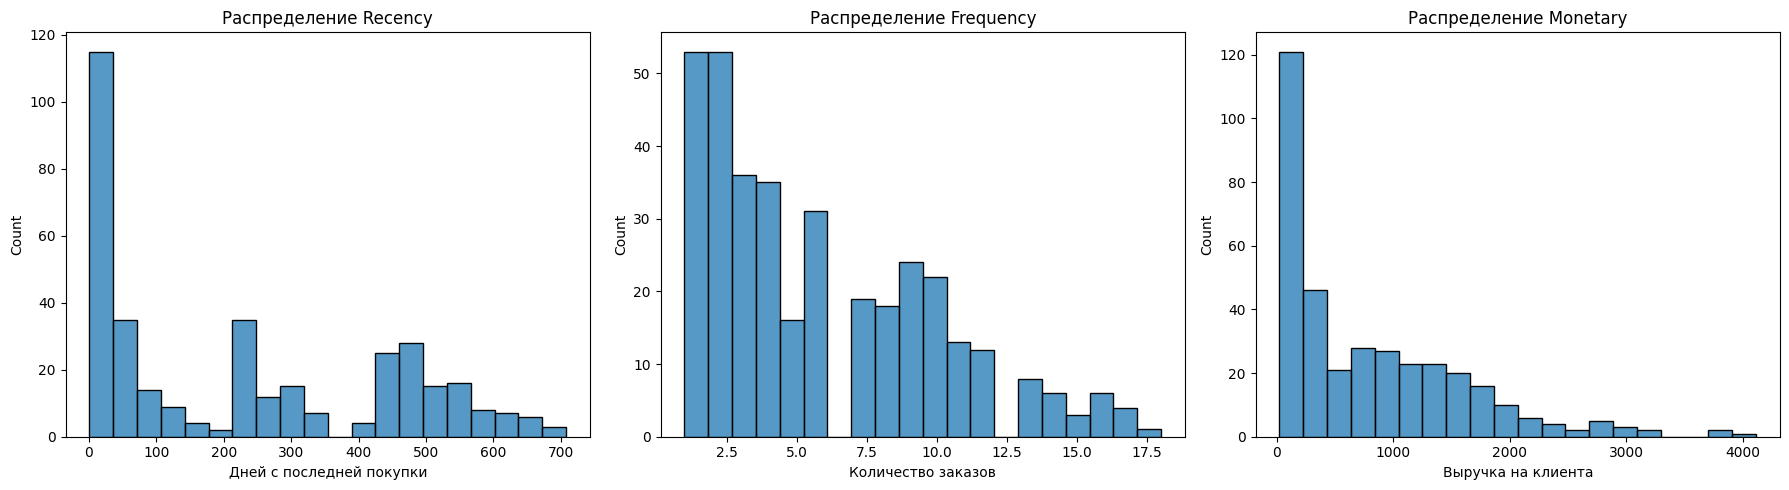

In [98]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(rfm['Recency'], bins=20)
plt.title('Распределение Recency')
plt.xlabel('Дней с последней покупки')

plt.subplot(1, 3, 2)
sns.histplot(rfm['Frequency'], bins=20)
plt.title('Распределение Frequency')
plt.xlabel('Количество заказов')

plt.subplot(1, 3, 3)
sns.histplot(rfm['Monetary'], bins=20)
plt.title('Распределение Monetary')
plt.xlabel('Выручка на клиента')

plt.tight_layout()
plt.show()

## Квантильный скоринг


In [99]:
rfm['R_Score'] = pd.qcut(rfm['Recency'].rank(method='first'), 5, labels=[5,4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)

# Объединение
rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Score'] = rfm[['R_Score','F_Score','M_Score']].sum(axis=1)

rfm.head(10)

,user_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score
0,U1001,11,9,1475.18,5,4,5,545,14
1,U1002,5,14,2236.34,5,5,5,555,15
2,U1003,31,11,1827.50,4,5,5,455,14
3,U1004,12,12,1921.36,5,5,5,555,15
4,U1005,1,13,2916.47,5,5,5,555,15
5,U1006,10,14,2064.70,5,5,5,555,15
6,U1007,6,10,1638.77,5,4,5,545,14
7,U1008,6,16,2694.98,5,5,5,555,15
8,U1009,15,15,2435.64,5,5,5,555,15
9,U1010,13,16,2218.80,5,5,5,555,15


## Сегментация клиентов



In [100]:
def assign_segment(row):
    r = row['R_Score']
    f = row['F_Score']
    m = row['M_Score']

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 4 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r == 3 and f >= 3 and m >= 3:
        return 'Sleeping Customers'
    elif r <= 2 and f >= 4 and m >= 4:
        return 'Lost Customers'
    elif r <= 2 and f >= 3:
        return 'High check Customers'
    elif r <= 2 and f <= 2:
        return 'Regular Customers'
    else:
        return 'Needs Attention'


In [101]:
rfm['Segment'] = rfm.apply(assign_segment, axis=1)
rfm[['RFM_Segment', 'RFM_Score', 'Segment']].head()

,RFM_Segment,RFM_Score,Segment
0,545,14,Champions
1,555,15,Champions
2,455,14,Champions
3,555,15,Champions
4,555,15,Champions


## Размер и ценность сегментов


In [102]:
segment_summary = rfm.groupby('Segment').agg(
    customers=('user_id', 'count'),
    total_revenue=('Monetary', 'sum'),
    avg_recency=('Recency', 'mean'),
    avg_frequency=('Frequency', 'mean'),
    avg_monetary=('Monetary', 'mean')
).reset_index()

segment_summary['customers_share_%'] = (
    segment_summary['customers'] / segment_summary['customers'].sum() * 100
)

segment_summary['revenue_share_%'] = (
    segment_summary['total_revenue'] / segment_summary['total_revenue'].sum() * 100
)

segment_summary = segment_summary.sort_values('total_revenue', ascending=False)

segment_summary.round(2)


,Segment,customers,total_revenue,avg_recency,avg_frequency,avg_monetary,customers_share_%,revenue_share_%
0,Champions,67,130335.31,18.16,12.09,1945.30,18.61,44.88
7,Sleeping Customers,70,76097.31,171.07,7.61,1087.10,19.44,26.20
2,Lost Customers,22,29236.95,312.18,8.50,1328.95,6.11,10.07
1,High check Customers,44,20988.30,442.75,4.50,477.01,12.22,7.23
5,New Customers,64,12533.93,23.09,1.88,195.84,17.78,4.32
6,Regular Customers,78,11384.97,521.67,1.92,145.96,21.67,3.92
3,Loyal Customers,13,9300.53,24.15,6.54,715.43,3.61,3.20
4,Needs Attention,2,525.02,152.50,2.50,262.51,0.56,0.18


In [103]:
rfm.to_csv('rfm_segments.csv', index=False)
segment_summary.to_csv('segment_summary.csv', index=False)


## Визуализация

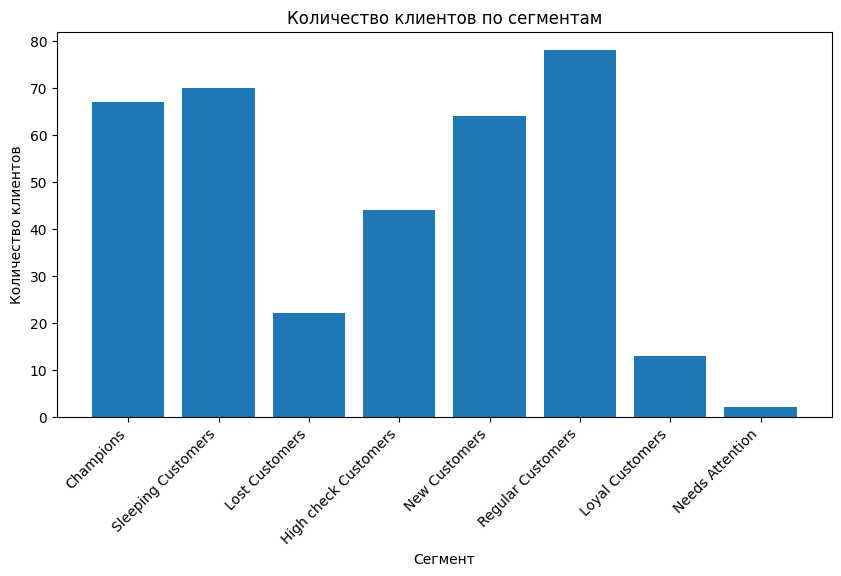

In [104]:
plt.figure(figsize=(10, 5))

plt.bar(segment_summary['Segment'], segment_summary['customers'])

plt.title('Количество клиентов по сегментам')
plt.xlabel('Сегмент')
plt.ylabel('Количество клиентов')
plt.xticks(rotation=45, ha='right')

plt.show()



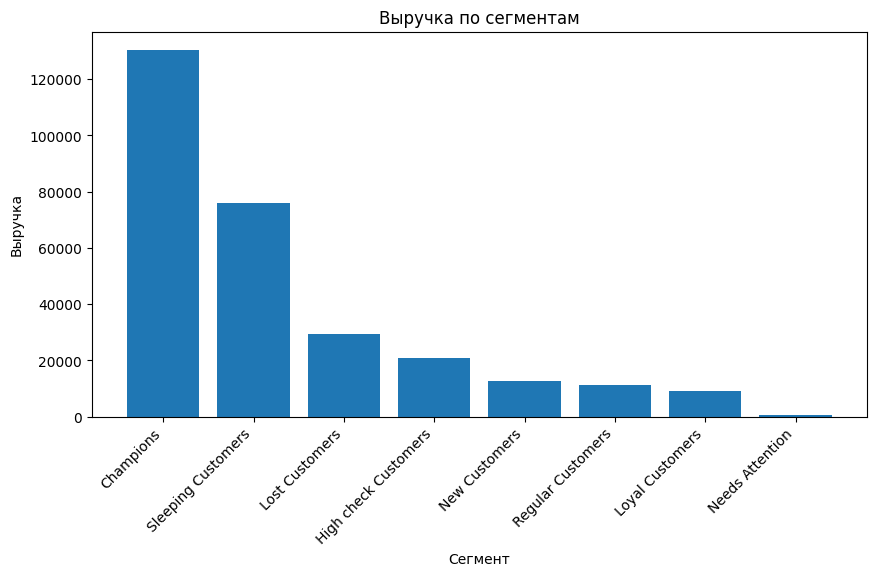

In [105]:
plt.figure(figsize=(10, 5))

plt.bar(segment_summary['Segment'], segment_summary['total_revenue'])

plt.title('Выручка по сегментам')
plt.xlabel('Сегмент')
plt.ylabel('Выручка')
plt.xticks(rotation=45, ha='right')

plt.show()

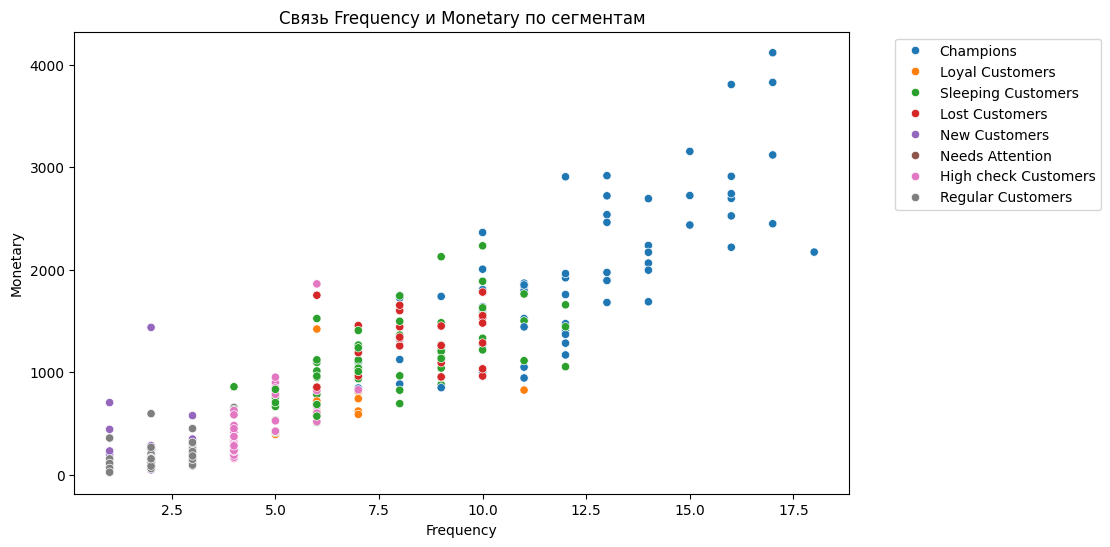

In [106]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Segment'
)

plt.title('Связь Frequency и Monetary по сегментам')
plt.xlabel('Frequency')
plt.ylabel('Monetary')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


## Бизнес-выводы

Самые ценные сегменты:
Champions - дают наибольшую выручку. Это ключевой сегмент для бизнеса.
Sleeping Customers - несмотря на снижение активности, раньше приносили много денег, поэтому их важно вернуть.

Кого удерживать:
Champions - персональные предложения, программа лояльности, ранний доступ к акциям.
Regular Customers - стимулировать рост среднего чека и частоты покупок.
New Customers - мотивировать на вторую покупку.

Кого реактивировать:
Sleeping Customers - персональные письма, промокод на возвращение, подборки товаров по прошлым покупкам.
Lost Customers - можно тестировать недорогие массовые кампании, но не тратить на них самый высокий бюджет.

Акции и коммуникации:
Champions - VIP-бонусы, закрытые распродажи, персональные рекомендации.
Regular Customers - накопительные бонусы, комплекты товаров, рекомендации.
New Customers - welcome-цепочка, скидка на второй заказ.
Sleeping Customers - “мы скучаем”, ограниченный промокод, подборки по прошлым категориям.
Lost Customers - реактивационная рассылка с простым оффером.
Needs Attention - проверить, почему сегмент маленький/слабый, и тестировать мягкие предложения.

Ограничения анализа:
RFM показывает только историю покупок: когда клиент покупал, как часто и на какую сумму.
Он не учитывает маржинальность, скидки, каналы привлечения, причины ухода, категории товаров и стоимость коммуникаций.